# Evaluation Metrics

In [ ]:
from __future__ import annotations

import copy
import os
import random
from datetime import datetime
from typing import TYPE_CHECKING

import matplotlib.pyplot as plt
import numpy as np
import pandapower as pp
import pandapower.plotting as plot
import pandas as pd
import simbench
from gymnasium import spaces
from matplotlib.dates import DateFormatter
from pandapower.networks import case14, case30, case118, case300, case2869pegase
from pandapower.powerflow import LoadflowNotConverged

from pandapower_env.data.example_configs import config_case30
from pandapower_env.action_space.action_space import (
    add_actions_substation_line_switching,
    create_actions_df,
    create_unitary_line_actions_and_donothing,
    create_unitary_substation_action,
    enforce_rules,
)
from pandapower_env.action_space.substation_action_rules import (
    passes_fully_connected_grid_rule,
    passes_islanded_elements_rule,
    passes_n_elements_rule,
    passes_two_bus_symmetry_rule,
)
from pandapower_env.agents.benchmark_agents import (
    DoNothingAgent,
    GreedyAgent,
    RandomAgent,
)
from pandapower_env.environments.simulation_env import (
    PPTopoGym,
)
from pandapower_env.observation_space.pp_to_observation import (
    clipped_line_loading_observation_space,
    line_loading_mean,
    line_overloading_percentage,
    line_overloading_sum,
    line_power_losses_sum,
    nminus1_bus_overloading_percentage,
    nminus1_line_loading_max,
    nminus1_line_loading_mean,
    nminus1_line_overloading_percentage,
    nminus1_line_overloading_sum,
    open_busbar_coupler_percentage,
)
from pandapower_env.substation.create_double_busbar_substation import (
    can_convert_to_n_busbar_substation,
    create_all_double_busbar_substations,
    n_assignable_elements_in_bus,
)
from pandapower_env.substation.plot_double_busbar_substation import (
    separate_substation_buses_visually,
)
from pandapower_env.toolbox.plotting_helpers import (
    calculate_externals_locations,
    label_lines,
    label_substations,
    plot_all_peripherals,
)
from pandapower_env.toolbox.utils import (
    run_nminus1_powerflow,
)
from pandapower_env.toolbox.utils_profiles import (
    add_random_profiles,
    get_profile_names,
    get_scenario_profiles,
    setup_profiles,
)
from pandapower_env.toolbox.utils_scaling import (
    find_max_timestep,
    find_scaling_binarysearch,
)

In [ ]:
# imports to show-case usage, actually only EvaluateMetrics is needed
from pandapower_env.metrics.evaluation_metrics import AllMetrics
from pandapower_env.metrics.metric_utils import EvaluateMetrics, MetricContainer

print("All functions available for evaluation:\n")
allmetrics = MetricContainer()


def all_subclasses(cls):
    return set(cls.__subclasses__()).union(
        [s for c in cls.__subclasses__() for s in all_subclasses(c)],
    )


def method_from_class(cls):
    return [func for func in dir(cls) if not func.startswith("__")]


all_subclasses_list = all_subclasses(allmetrics.__class__)
method_dict_name_class = {}
for subclass in all_subclasses_list:
    for func in method_from_class(subclass):
        method_dict_name_class[func] = subclass

for method, class_ in method_dict_name_class.items():
    func = getattr(class_, method)
    print(func.get_name())

In [3]:
# Imports


In [4]:
env_config = config_case30()

env_config_copy = copy.deepcopy(env_config)

simenv = PPTopoGym(env_config)
net = env_config["net"]
actions = env_config["action_space"]
loads_begin = copy.deepcopy(net.load["profile"].unique().tolist())
gens_begin = copy.deepcopy(net.gen["profile"].unique().tolist())
sgens_begin = copy.deepcopy(net.sgen["profile"].unique().tolist())

In [5]:
# Load and run Agent and store the taken actions
# import agents

In [6]:
# Evaluate the agent
taken_actions = {}
actions_gym = spaces.Discrete(len(actions))
agents = [
    DoNothingAgent(actions_gym),
    # GreedyAgent(actions_gym, env_config),
]
agent = agents[0]
simenv = PPTopoGym(env_config)
id_start = 0
timesteps = 6
id_end = id_start + timesteps
step_size = 1
# run agents
max_loading_percent_all_agents = []
max_nminus1_all_agents = []
print(f"Start running agent {agent.__class__.__name__}")
max_loading_percent = []
max_nminus1_loading_percent = []
# simenv.reset()
# pp.runpp(simenv.net)
for id_, time in enumerate(range(id_start, id_end - 3, step_size)):
    obs = simenv.create_observation()
    terminated = False
    try:
        action = agent.act(observation=obs)
    except TypeError:
        action = agent.act()
    obs_step, reward, terminated, truncated, info = simenv.step(action)
    nminus0 = np.max(obs_step["line_loadings"])
    # create nminus1 observation
    try:
        pp.runpp(simenv.net)
        run_nminus1_powerflow(simenv.net)
        obs_step["nminus1"] = np.max(nminus1_line_loading_max(simenv.net))
    except LoadflowNotConverged:
        obs_step["nminus1"] = float("inf")
    nminus1 = np.max(obs_step["nminus1"])
    max_loading_percent.append(nminus0)
    max_nminus1_loading_percent.append(nminus1)
    print(f"Step {id_+1}: time {time}, {action} Results -> N-0: {nminus0}, N-1: {nminus1}")
    if terminated:
        break
print(f"Episode finished after {id_+1} timesteps.")
max_nminus1_all_agents.append(max_nminus1_loading_percent)
max_loading_percent_all_agents.append(max_loading_percent)
taken_actions[agent.__class__.__name__] = simenv.log_actions
print(
    f"Finished running agent {agent.__class__.__name__} with the actions {taken_actions[agent.__class__.__name__]}",
)

Start running agent DoNothingAgent
Step 1: time 0, 0 Results -> N-0: 64.67789459228516, N-1: 116.0421726251262
Step 2: time 1, 0 Results -> N-0: 63.79985046386719, N-1: 116.16232117427172
Step 3: time 2, 0 Results -> N-0: 63.96092987060547, N-1: 115.55956088422906
Episode finished after 3 timesteps.
Finished running agent DoNothingAgent with the actions [0 0 0]


In [7]:
actions = simenv.log_actions  # for try-out
eval = EvaluateMetrics(env_config_copy, actions)
eval.run()
print("All metrics executed. Each metric comes with a dictionary, with the keys 'value' (result) and 'cache' (intermediate values).")
print(eval)

All metrics executed. Each metric comes with a dictionary, with the keys 'value' (result) and 'cache' (intermediate values).
FloatMetric(name=action_entropy)
action_entropy: value=-0.0, cache={'actions': [0, 0, 0]}
FloatMetric(name=average_reward)
average_reward: value=135.85377574318036, cache={'rewards': [np.float64(135.3221057319946), np.float64(136.200150633466), np.float64(136.0390708640805)]}
FloatMetric(name=line_max_timestep_overload_nminus0)
line_max_timestep_overload_nminus0: value=0.0, cache={'highest_timestep_one_line_overloaded': [0, 0, 0], 'lines_overloaded': [[False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False], [False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, Fal

In [8]:
print("All metric results are saved in a dictionary, with access to value and cache.")
print(eval.gather_results())

All metric results are saved in a dictionary, with access to value and cache.
{'action_entropy': {'value': -0.0, 'cache': {'actions': [0, 0, 0]}}, 'average_reward': {'value': np.float64(135.85377574318036), 'cache': {'rewards': [np.float64(135.3221057319946), np.float64(136.200150633466), np.float64(136.0390708640805)]}}, 'line_max_timestep_overload_nminus0': {'value': 0.0, 'cache': {'highest_timestep_one_line_overloaded': [0, 0, 0], 'lines_overloaded': [[False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False], [False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False,

# Run more metrics and plot them

Evaluations for:
DoNothingAgent: 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0
GreedyAgent: 47, 164, 18, 186, 27, 151, 159, 16, 205, 106, 182, 1, 18, 12, 156, 125, 14, 197, 2, 124, 180, 201, 4, 223
NminusOneGreedyAgent: 49, 198, 223, 207, 156, 106, 269, 153, 206, 257, 155, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [9]:
donothing_actions = [
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
] * 4

greedy_actions = [
    47,
    164,
    18,
    186,
    27,
    151,
    159,
    16,
    205,
    106,
    182,
    1,
    18,
    12,
    156,
    125,
    14,
    197,
    2,
    124,
    180,
    201,
    4,
    223,
]
nminus1Greedy_actions = [
    49,
    198,
    223,
    207,
    156,
    106,
    269,
    153,
    206,
    257,
    155,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
    0,
]

# Based on data.example_configs

In [10]:
taken_actions = dict()
actions = [188, 46, 91, 8, 172, 0, 50, 91, 113, 88, 163, 114, 51, 91, 262, 87, 94, 2, 93, 104, 93, 65, 155, 343, 344, 234, 191, 242, 85, 6, 89, 0, 66, 45, 0, 89, 87, 92, 10, 93, 75, 253, 21, 178, 264, 39, 72, 108, 157, 75, 108, 72, 297, 166, 80, 100, 78, 72, 158, 236, 100, 76, 98, 210, 248, 114, 221, 215, 249, 68, 298, 260, 20, 79, 2, 12, 28, 166, 49, 105, 171, 163, 150, 100, 79, 164, 329, 222, 0, 113, 161, 72, 155, 191, 245, 75]
taken_actions["GreedyNminus0"] = actions

In [11]:
from pandapower_env.data.example_configs import config_case30

env_config = config_case30()
env_config_copy = copy.deepcopy(env_config)
eval = EvaluateMetrics(env_config_copy, actions)
eval.run()
results = eval.gather_results()
print(results)

print(next(iter(results["max_line_loading_nminus0"]["cache"].values())))


line 0 causes Power Flow nr did not converge after 10 iterations!
line 4 causes Power Flow nr did not converge after 10 iterations!
line 7 causes Power Flow nr did not converge after 10 iterations!
line 8 causes Power Flow nr did not converge after 10 iterations!


{'action_entropy': {'value': 4.152650896412677, 'cache': {'actions': [188, 46, 91, 8, 172, 0, 50, 91, 113, 88, 163, 114, 51, 91, 262, 87, 94, 2, 93, 104, 93, 65, 155, 343, 344, 234, 191, 242, 85, 6, 89, 0, 66, 45, 0, 89, 87, 92, 10, 93, 75, 253, 21, 178, 264, 39, 72, 108, 157, 75, 108, 72, 297, 166, 80, 100, 78, 72, 158, 236, 100, 76, 98, 210, 248, 114, 221, 215, 249, 68, 298, 260, 20, 79, 2, 12, 28, 166, 49, 105, 171, 163, 150, 100, 79, 164, 329, 222, 0, 113, 161, 72, 155, 191, 245, 75]}}, 'average_reward': {'value': np.float64(121.75303110322193), 'cache': {'rewards': [np.float64(135.48940814356905), np.float64(132.1689255217973), np.float64(127.77795699796289), np.float64(85.52416428446563), np.float64(85.80160892412319), np.float64(113.7595879902204), np.float64(124.30489991788201), np.float64(111.69231860672282), np.float64(86.92927227400105), np.float64(106.32945085084017), np.float64(114.46123643577795), np.float64(114.56139101126817), np.float64(123.75877509942316), np.float64(

In [12]:
for key, value in results.items():
    print(f"{key}: {value['value']}")

action_entropy: 4.152650896412677
average_reward: 121.75303110322193
line_max_timestep_overload_nminus0: 11.0
max_line_loading_absolute_nminus0: 4.0
max_line_loading_mean_nminus0: 37.29780487364534
max_line_loading_nminus0: 190.49313183171526
max_line_loading_nminus1: 449.75032063210153
open_busbar_couplers: 9.0
open_busbar_couplers_window_32ts: 9.0
sum_line_loading_nminus0: 22.0


In [ ]:
print("Start training of a greedy agent")
env_config_greedy = copy.deepcopy(env_config)
env_config_env = copy.deepcopy(env_config)
env = PPTopoGym(env_config_env)
actions = spaces.Discrete(len(env_config_greedy["action_space"]))
greedy = GreedyAgent(actions, env_config_greedy, n_workers = 16)
obs, info = env.reset(options = {"index": 0})
for i in range(96): # a whole episode has 96 values
    action = greedy.act(obs, info)
    obs, _, _, _, info = env.step(action)
taken_actions["GreedyAgent"] = env.log_actions


Start training of a greedy agent


In [14]:
agent_results = {}
agent_results["GreedyNminus0"] = results

In [15]:
# same for DoNothing
actions_dn = [0]*96
env_config_copy = copy.deepcopy(env_config)
eval = EvaluateMetrics(env_config_copy, actions_dn)
eval.run()
results_dn = eval.gather_results()
agent_results["DoNothing"] = results_dn
taken_actions["DoNothing"] = actions_dn

In [18]:
# plots for all metrics: One Plot per Metric, each plot: DoNothing, N-0 Greedy
agent_results["DoNothing"].keys()


dict_keys(['action_entropy', 'average_reward', 'line_max_timestep_overload_nminus0', 'max_line_loading_absolute_nminus0', 'max_line_loading_mean_nminus0', 'max_line_loading_nminus0', 'max_line_loading_nminus1', 'open_busbar_couplers', 'open_busbar_couplers_window_32ts', 'sum_line_loading_nminus0'])

KeyError: 'GreedyAgent'

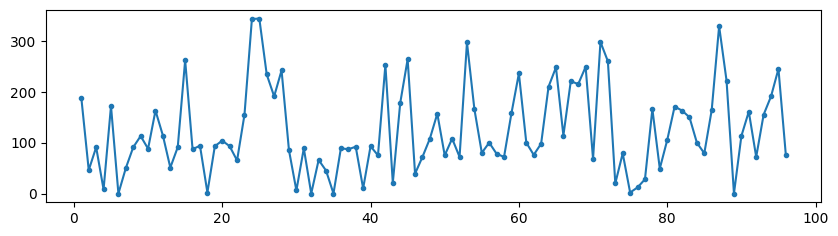

In [19]:
# plot
# Save figure as PDF
# Extract data

metrics = agent_results["DoNothing"].keys()
# agent_name = "GreedyNminus0"
for metric in metrics:
    # Create plot N-0
    cmap = plt.get_cmap("tab10")
    plt.figure(figsize=(10, 2.5))
    steps = range(1, 96 + 1) # 96 hardcoded
    # Set colormap and line styles
    cmap = plt.get_cmap("tab10")
    line_styles = ["-", "--", "-.", ":"]
    for idx, agent_name in enumerate(taken_actions.keys()):
        color = cmap(idx % cmap.N)
        plt.plot(
            steps,
            next(iter(agent_results[agent_name][metric]["cache"].values())),
            label=agent_name,
            linestyle=line_styles[idx % len(line_styles)],
            marker="o",
            markersize=3,
            color=color,
        )
    plt.axhline(y=100, color="black", linestyle="-", linewidth=1.5, label="Threshold 100")
    plt.xlabel("Step")
    plt.ylabel(metric)
    plt.title(metric.replace("_", " ").title())
    plt.legend()
    plt.grid(True)



    # Create the directory if it doesn't exist
    output_dir = "plots"
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(f"plots/{metric}.pdf", format="pdf")
    plt.show()

In [39]:
env.reset(options={"index": 0})
env.run_pf()


True

In [40]:
print(max(env.net.res_line["loading_percent"]))

78.77992367963469


In [41]:
# all metrics
results = eval.gather_results()
metrics = results.keys()

In [42]:
import pandapower as pp

from pandapower_env.data.example_configs import config_case30

config = config_case30()
net = config["net"]
pp.runpp(net)
print(max(net.res_line["loading_percent"]))

14.019591289497201
